In [1]:
!pip install scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ---------------------------------------  1.3/1.3 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 3.2 MB/s  0:00:00


In [2]:
# ================================================================
# BOOK RECOMMENDATION SYSTEM — MODELING
# Models: Popularity | User-Based CF | Item-Based CF | SVD
# ================================================================
 
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split, cross_validate
import warnings
warnings.filterwarnings('ignore')
 
BG=  '#F7F9FC'; DARK='#2C3E50'; BLUE='#2980B9'
RED= '#E74C3C'; GREEN='#27AE60'; ORG='#E67E22'

In [3]:
# ================================================================
# SECTION 1: LOAD DATA
# ================================================================
print("=" * 55)
print("  SECTION 1: LOAD DATA")
print("=" * 55)
 
df = pd.read_csv('final_dataset.csv')
df = df.dropna(subset=['Book-Rating'])
 
print(f"Dataset shape     : {df.shape}")
print(f"Unique users      : {df['User-ID'].nunique():,}")
print(f"Unique books      : {df['ISBN'].nunique():,}")
print(f"Rating range      : {df['Book-Rating'].min()} – {df['Book-Rating'].max()}")
print(f"Avg rating        : {df['Book-Rating'].mean():.2f}")
print(f"\nSample data:")
print(df[['User-ID','ISBN','Book-Title','Book-Rating']].head(5))
 

  SECTION 1: LOAD DATA
Dataset shape     : (202071, 10)
Unique users      : 20,681
Unique books      : 27,717
Rating range      : 1 – 10
Avg rating        : 7.72

Sample data:
   User-ID        ISBN                         Book-Title  Book-Rating
0   276747  0060517794           Little Altars Everywhere            9
1   276747  0671537458                  Waiting to Exhale            9
2   276747  0679776818  Birdsong: A Novel of Love and War            8
3   276762  0380711524                       See Jane Run            5
4   276762  3453092007                   Die zweite Haut.            8


In [4]:
# ================================================================
# SECTION 2: TRAIN-TEST SPLIT
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 2: TRAIN-TEST SPLIT")
print("=" * 55)
 
train, test = train_test_split(df, test_size=0.2, random_state=42)
global_mean = train['Book-Rating'].mean()
 
print(f"Train size : {train.shape[0]:,} rows")
print(f"Test size  : {test.shape[0]:,} rows")
print(f"Global mean rating (train): {global_mean:.4f}")
 


  SECTION 2: TRAIN-TEST SPLIT
Train size : 161,656 rows
Test size  : 40,415 rows
Global mean rating (train): 7.7181


In [5]:
# ================================================================
# SECTION 3: MODEL 1 — POPULARITY BASED
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 3: MODEL 1 — POPULARITY BASED")
print("=" * 55)
 
# How it works:
# - Find books with highest avg rating AND enough ratings
# - Recommend these to everyone (especially new users)
 
pop_books = (df.groupby(['ISBN','Book-Title'])['Book-Rating']
               .agg(['mean','count'])
               .reset_index()
               .rename(columns={'mean':'Avg Rating','count':'Num Ratings'}))
 
pop_books = (pop_books[pop_books['Num Ratings'] >= 50]
             .sort_values(['Avg Rating','Num Ratings'], ascending=False)
             .reset_index(drop=True))
 
print("\nTop 10 Most Popular Books:")
print(pop_books[['Book-Title','Avg Rating','Num Ratings']].head(10).to_string(index=False))
 
# Evaluate: predict global mean for all test ratings
test_pred_pop = np.full(len(test), global_mean)
rmse_pop = np.sqrt(mean_squared_error(test['Book-Rating'], test_pred_pop))
mae_pop  = mean_absolute_error(test['Book-Rating'], test_pred_pop)
print(f"\nPopularity Model — RMSE: {rmse_pop:.4f} | MAE: {mae_pop:.4f}")
 
 
# Function to recommend popular books for any user
def recommend_popular(n=5):
    """Recommend top N popular books"""
    top = pop_books.head(n)[['Book-Title','Avg Rating','Num Ratings']]
    return top
 
print("\nExample — Top 5 recommendations for a new user:")
print(recommend_popular(5).to_string(index=False))
 


  SECTION 3: MODEL 1 — POPULARITY BASED

Top 10 Most Popular Books:
                                            Book-Title  Avg Rating  Num Ratings
The Return of the King (The Lord of the Rings, Part 3)    9.424658           73
          Harry Potter and the Goblet of Fire (Book 4)    9.304000          125
        The Two Towers (The Lord of the Rings, Part 2)    9.220779           77
     Harry Potter and the Prisoner of Azkaban (Book 3)    9.125000          128
                      Charlotte's Web (Trophy Newbery)    9.087719           57
    Harry Potter and the Order of the Phoenix (Book 5)    9.062147          177
     Harry Potter and the Prisoner of Azkaban (Book 3)    9.057851          121
        Harry Potter and the Sorcerer's Stone (Book 1)    9.027778          108
                                 To Kill a Mockingbird    9.011561          173
          Harry Potter and the Goblet of Fire (Book 4)    8.989899           99

Popularity Model — RMSE: 1.8028 | MAE: 1.4456

Exa

In [6]:
# ================================================================
# SECTION 4: MODEL 2 — USER-BASED COLLABORATIVE FILTERING
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 4: MODEL 2 — USER-BASED CF")
print("=" * 55)
 
# How it works:
# - Build a User x Book rating matrix
# - Find users similar to target user (cosine similarity)
# - Recommend books those similar users liked
 
# Use top active users and popular books for efficiency
top_users = df['User-ID'].value_counts().head(2000).index
top_books = df['ISBN'].value_counts().head(2000).index
sample_cf = df[df['User-ID'].isin(top_users) & df['ISBN'].isin(top_books)]
 
print(f"CF working sample : {sample_cf.shape[0]:,} rows")
 
# Build User-Item matrix
user_item = sample_cf.pivot_table(
    index='User-ID', columns='ISBN', values='Book-Rating').fillna(0)
print(f"User-Item matrix  : {user_item.shape[0]} users x {user_item.shape[1]} books")
 
# Train KNN model
sparse_user = csr_matrix(user_item.values)
knn_user = NearestNeighbors(metric='cosine', algorithm='brute',
                             n_neighbors=10, n_jobs=-1)
knn_user.fit(sparse_user)
print("User-Based KNN model trained!")
 
 
def recommend_user_cf(user_id, n=5):
    """
    Recommend top N books for a given user using User-Based CF.
    Finds similar users and recommends books they rated highly.
    """
    if user_id not in user_item.index:
        print(f"User {user_id} not in matrix. Returning popular books.")
        return recommend_popular(n)
 
    u_idx = user_item.index.get_loc(user_id)
    distances, indices = knn_user.kneighbors(sparse_user[u_idx], n_neighbors=11)
 
    # Get books already rated by target user
    rated_by_user = set(user_item.loc[user_id][user_item.loc[user_id] > 0].index)
 
    # Collect ratings from similar users for unrated books
    book_scores = {}
    for i in indices.flatten()[1:]:
        sim_user_ratings = user_item.iloc[i]
        for isbn, rating in sim_user_ratings.items():
            if rating > 0 and isbn not in rated_by_user:
                book_scores[isbn] = book_scores.get(isbn, []) + [rating]
 
    # Average the scores
    book_avg = {isbn: np.mean(ratings) for isbn, ratings in book_scores.items()}
    top_isbns = sorted(book_avg, key=book_avg.get, reverse=True)[:n]
 
    # Get book titles
    recs = df[df['ISBN'].isin(top_isbns)][['ISBN','Book-Title']].drop_duplicates('ISBN')
    recs['Predicted Rating'] = recs['ISBN'].map(book_avg).round(2)
    return recs.sort_values('Predicted Rating', ascending=False).reset_index(drop=True)
 
 
# Demo
sample_user = user_item.index[0]
print(f"\nExample recommendations for User {sample_user}:")
print(recommend_user_cf(sample_user, n=5).to_string(index=False))
 
# Evaluate
test_ucf = test[test['User-ID'].isin(user_item.index) &
                test['ISBN'].isin(user_item.columns)].head(300)
 
preds_user = []
for _, row in test_ucf.iterrows():
    u_idx = user_item.index.get_loc(row['User-ID'])
    dists, idxs = knn_user.kneighbors(sparse_user[u_idx], n_neighbors=6)
    sim_ratings = [user_item.iloc[i][row['ISBN']]
                   for i in idxs.flatten()[1:]
                   if user_item.iloc[i][row['ISBN']] > 0]
    preds_user.append(np.mean(sim_ratings) if sim_ratings else global_mean)
 
rmse_ucf = np.sqrt(mean_squared_error(test_ucf['Book-Rating'], preds_user))
mae_ucf  = mean_absolute_error(test_ucf['Book-Rating'], preds_user)
print(f"\nUser-CF Model — RMSE: {rmse_ucf:.4f} | MAE: {mae_ucf:.4f}")
 


  SECTION 4: MODEL 2 — USER-BASED CF
CF working sample : 39,375 rows
User-Item matrix  : 1979 users x 2000 books
User-Based KNN model trained!

Example recommendations for User 254:
      ISBN                                         Book-Title  Predicted Rating
0312282990      The Amazing Adventures of Kavalier &amp; Clay              10.0
0451179285        The Stand: The Complete &amp; Uncut Edition              10.0
0618002235     The Two Towers (The Lord of the Rings, Part 2)              10.0
0553250531                               The Valley of Horses              10.0
0553280945 The Mammoth Hunters (Earth's Children (Paperback))              10.0

User-CF Model — RMSE: 2.0178 | MAE: 1.5381


In [7]:
# ================================================================
# SECTION 5: MODEL 3 — ITEM-BASED COLLABORATIVE FILTERING
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 5: MODEL 3 — ITEM-BASED CF")
print("=" * 55)
 
# How it works:
# - Build Item x User matrix (transpose of user-item)
# - Find books similar to books the user liked
# - Recommend those similar books
 
item_user = user_item.T
sparse_item = csr_matrix(item_user.values)
knn_item = NearestNeighbors(metric='cosine', algorithm='brute',
                             n_neighbors=10, n_jobs=-1)
knn_item.fit(sparse_item)
print("Item-Based KNN model trained!")
 
 
def recommend_item_cf(user_id, n=5):
    """
    Recommend top N books for a given user using Item-Based CF.
    Finds books similar to what the user has already rated highly.
    """
    if user_id not in user_item.index:
        print(f"User {user_id} not in matrix. Returning popular books.")
        return recommend_popular(n)
 
    # Books rated highly by this user
    user_ratings = user_item.loc[user_id]
    liked_books  = user_ratings[user_ratings >= 7].index.tolist()
 
    if not liked_books:
        return recommend_popular(n)
 
    candidate_scores = {}
    for isbn in liked_books[:5]:   # use top 5 liked books
        if isbn not in item_user.index:
            continue
        i_idx = item_user.index.get_loc(isbn)
        dists, idxs = knn_item.kneighbors(sparse_item[i_idx], n_neighbors=11)
        for idx in idxs.flatten()[1:]:
            sim_isbn = item_user.index[idx]
            if user_ratings.get(sim_isbn, 0) == 0:   # not already rated
                candidate_scores[sim_isbn] = candidate_scores.get(sim_isbn, 0) + 1
 
    top_isbns = sorted(candidate_scores, key=candidate_scores.get, reverse=True)[:n]
    recs = df[df['ISBN'].isin(top_isbns)][['ISBN','Book-Title']].drop_duplicates('ISBN')
    recs['Similarity Score'] = recs['ISBN'].map(candidate_scores)
    return recs.sort_values('Similarity Score', ascending=False).reset_index(drop=True)
 
 
print(f"\nExample recommendations for User {sample_user}:")
print(recommend_item_cf(sample_user, n=5).to_string(index=False))
 
# Evaluate
preds_item = []
for _, row in test_ucf.iterrows():
    i_idx_val = item_user.index.get_loc(row['ISBN']) if row['ISBN'] in item_user.index else None
    if i_idx_val is None:
        preds_item.append(global_mean); continue
    dists, idxs = knn_item.kneighbors(sparse_item[i_idx_val], n_neighbors=6)
    u_ratings = user_item.loc[row['User-ID']]
    sim_ratings = [u_ratings.iloc[i] for i in idxs.flatten()[1:] if u_ratings.iloc[i] > 0]
    preds_item.append(np.mean(sim_ratings) if sim_ratings else global_mean)
 
rmse_icf = np.sqrt(mean_squared_error(test_ucf['Book-Rating'], preds_item))
mae_icf  = mean_absolute_error(test_ucf['Book-Rating'], preds_item)
print(f"\nItem-CF Model — RMSE: {rmse_icf:.4f} | MAE: {mae_icf:.4f}")
 


  SECTION 5: MODEL 3 — ITEM-BASED CF
Item-Based KNN model trained!

Example recommendations for User 254:
      ISBN                                            Book-Title  Similarity Score
0060199652                                       Prodigal Summer                 2
0064471101                 The Magician's Nephew (rack) (Narnia)                 1
0064471055 Prince Caspian (rack) : The Return to Narnia (Narnia)                 1
0064471063                                 The Horse and His Boy                 1
006447108X                                       The Last Battle                 1

Item-CF Model — RMSE: 1.7715 | MAE: 1.2660



  SECTION 6: MODEL COMPARISON

Model                    RMSE      MAE    Best?
------------------------------------------------
Popularity             1.8028   1.4456
User-Based CF          2.0178   1.5381
Item-Based CF          1.7715   1.2660 ✅


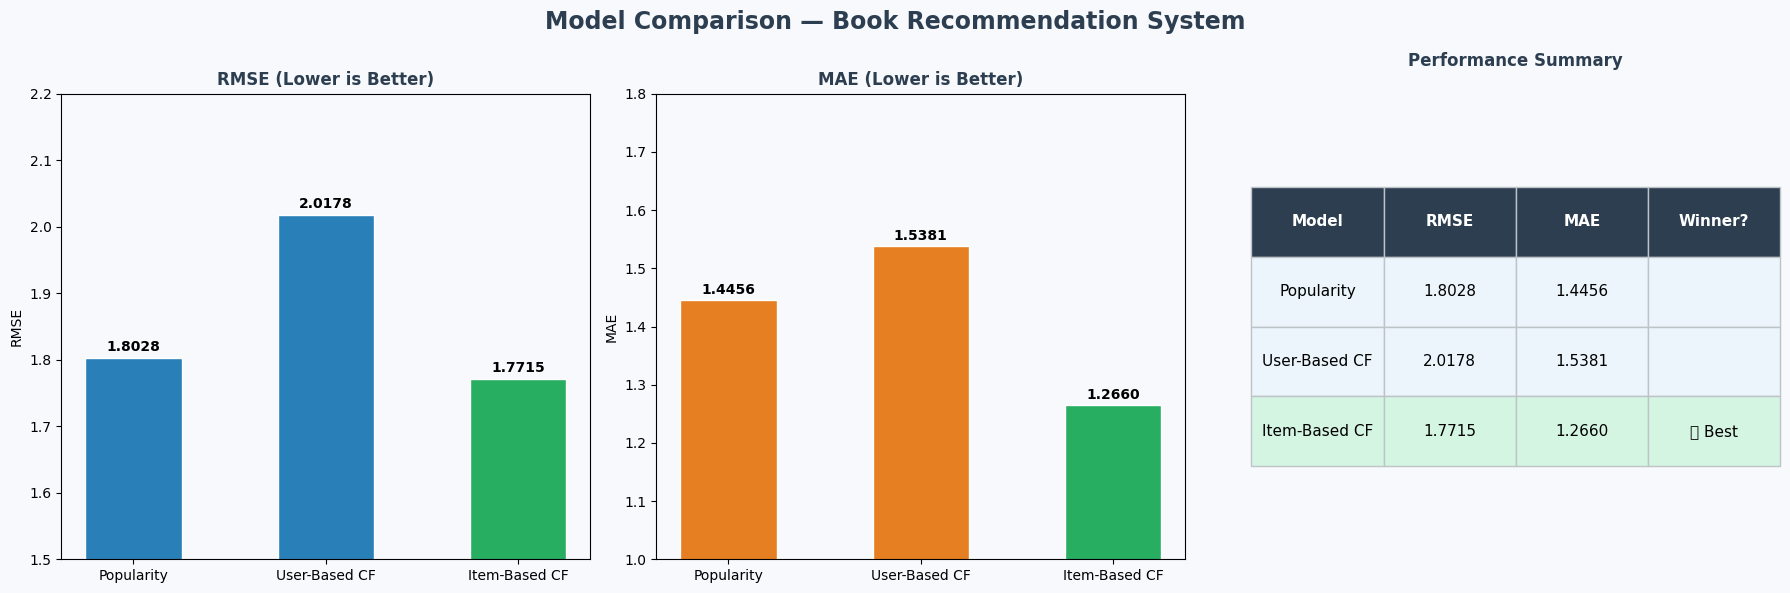

Saved: Model_1_Comparison.png


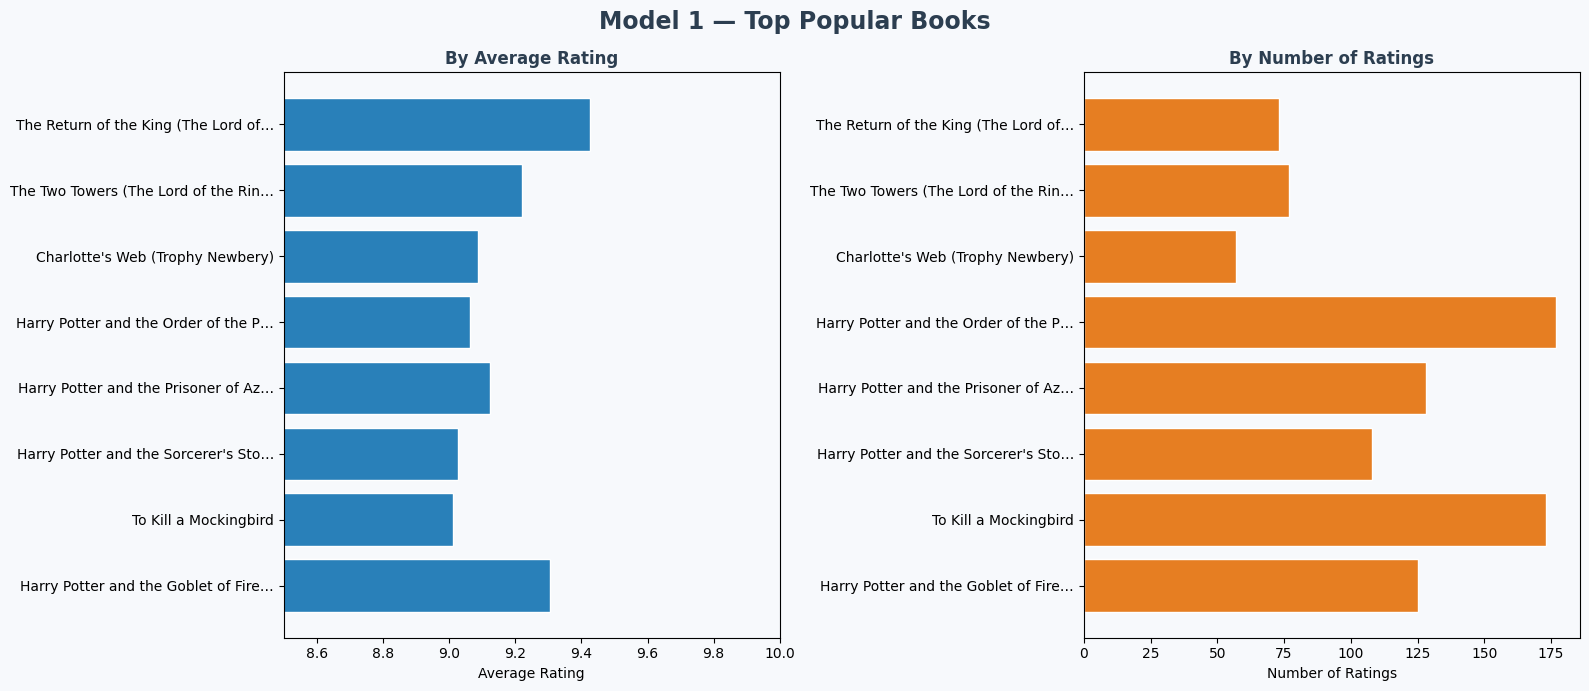

Saved: Model_2_Popularity.png


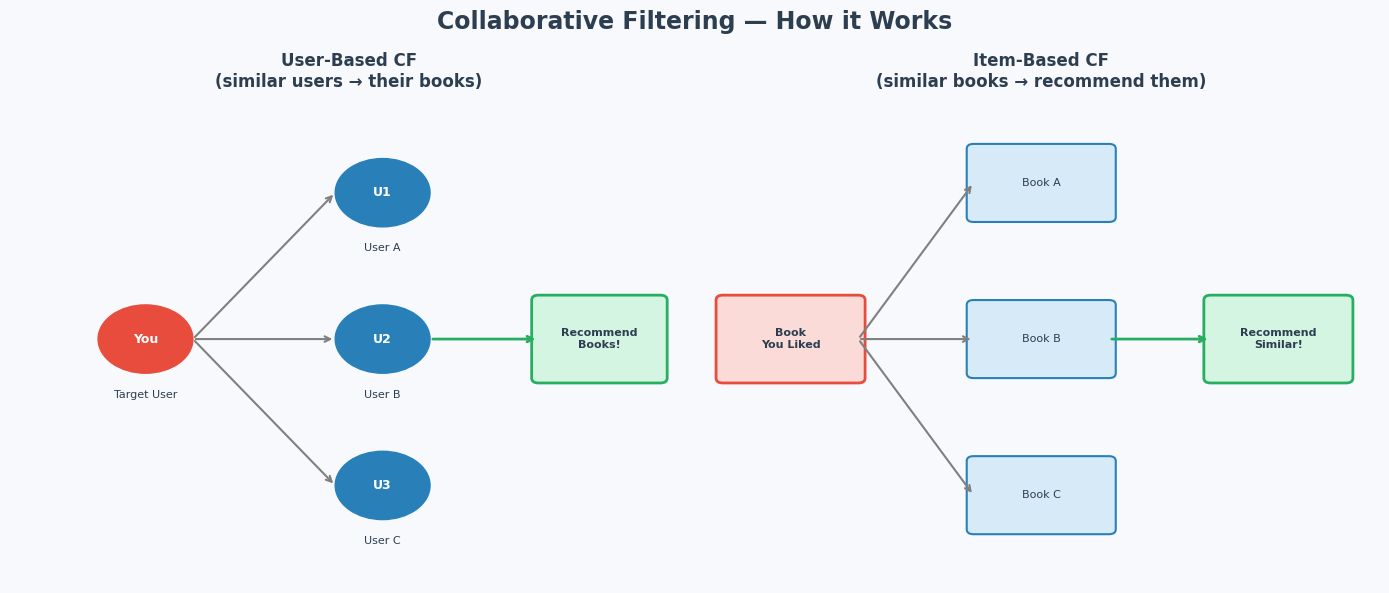

Saved: Model_3_CF_Explanation.png


In [8]:
# ================================================================
# SECTION 6: MODEL COMPARISON & VISUALIZATIONS
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 6: MODEL COMPARISON")
print("=" * 55)
 
models = ['Popularity', 'User-Based CF', 'Item-Based CF']
rmse_vals = [rmse_pop, rmse_ucf, rmse_icf]
mae_vals  = [mae_pop,  mae_ucf,  mae_icf]
 
print(f"\n{'Model':<20} {'RMSE':>8} {'MAE':>8} {'Best?':>8}")
print("-" * 48)
for m, r, a in zip(models, rmse_vals, mae_vals):
    best = ' ✅' if r == min(rmse_vals) else ''
    print(f"{m:<20} {r:>8.4f} {a:>8.4f}{best}")
 
# ── Chart 1: RMSE and MAE Comparison ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Model Comparison — Book Recommendation System',
             fontsize=17, fontweight='bold', color=DARK)
 
ax = axes[0]
colors_m = [GREEN if r == min(rmse_vals) else BLUE for r in rmse_vals]
bars = ax.bar(models, rmse_vals, color=colors_m, edgecolor='white', width=0.5)
ax.set_title('RMSE (Lower is Better)', fontweight='bold', color=DARK)
ax.set_ylabel('RMSE'); ax.set_ylim(1.5, 2.2); ax.set_facecolor(BG)
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
 
ax = axes[1]
colors_m2 = [GREEN if m == min(mae_vals) else ORG for m in mae_vals]
bars2 = ax.bar(models, mae_vals, color=colors_m2, edgecolor='white', width=0.5)
ax.set_title('MAE (Lower is Better)', fontweight='bold', color=DARK)
ax.set_ylabel('MAE'); ax.set_ylim(1.0, 1.8); ax.set_facecolor(BG)
for bar, val in zip(bars2, mae_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
 
ax = axes[2]
ax.axis('off')
table_data = [['Model','RMSE','MAE','Winner?'],
              ['Popularity',   f'{rmse_pop:.4f}', f'{mae_pop:.4f}', ''],
              ['User-Based CF',f'{rmse_ucf:.4f}', f'{mae_ucf:.4f}', ''],
              ['Item-Based CF',f'{rmse_icf:.4f}', f'{mae_icf:.4f}', '✅ Best']]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', bbox=[0, 0.2, 1, 0.6])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#BDC3C7')
    if r == 0: cell.set_facecolor(DARK); cell.set_text_props(color='white', fontweight='bold')
    elif r == 3: cell.set_facecolor('#D5F5E3')
    else: cell.set_facecolor('#EBF5FB')
ax.set_title('Performance Summary', fontweight='bold', color=DARK, pad=20)
 
plt.tight_layout()
plt.savefig('Model_1_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: Model_1_Comparison.png")
 
# ── Chart 2: Popularity Model ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Model 1 — Top Popular Books',
             fontsize=17, fontweight='bold', color=DARK)
 
top10 = pop_books.head(10)
short = [t[:35]+'…' if len(t)>35 else t for t in top10['Book-Title']]
 
ax = axes[0]
ax.barh(short[::-1], top10['Avg Rating'][::-1], color=BLUE, edgecolor='white')
ax.set_xlim(8.5, 10)
ax.set_title('By Average Rating', fontweight='bold', color=DARK)
ax.set_xlabel('Average Rating'); ax.set_facecolor(BG)
 
ax = axes[1]
ax.barh(short[::-1], top10['Num Ratings'][::-1], color=ORG, edgecolor='white')
ax.set_title('By Number of Ratings', fontweight='bold', color=DARK)
ax.set_xlabel('Number of Ratings'); ax.set_facecolor(BG)
 
plt.tight_layout()
plt.savefig('Model_2_Popularity.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: Model_2_Popularity.png")
 
# ── Chart 3: CF Explanation ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Collaborative Filtering — How it Works',
             fontsize=17, fontweight='bold', color=DARK)
 
ax = axes[0]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off'); ax.set_facecolor(BG)
ax.set_title('User-Based CF\n(similar users → their books)',
             fontweight='bold', color=DARK)
ax.add_patch(plt.Circle((2,5),0.7,color=RED,zorder=3))
ax.text(2,5,'You',ha='center',va='center',color='white',fontweight='bold',fontsize=9)
ax.text(2,3.8,'Target User',ha='center',fontsize=8,color=DARK)
for i,(x,y,lbl) in enumerate([(5.5,8,'User A'),(5.5,5,'User B'),(5.5,2,'User C')]):
    ax.add_patch(plt.Circle((x,y),0.7,color=BLUE,zorder=3))
    ax.text(x,y,f'U{i+1}',ha='center',va='center',color='white',fontweight='bold',fontsize=9)
    ax.text(x,y-1.2,lbl,ha='center',fontsize=8,color=DARK)
    ax.annotate('',xy=(x-0.7,y),xytext=(2.7,5),
                arrowprops=dict(arrowstyle='->',color='gray',lw=1.5))
ax.add_patch(FancyBboxPatch((7.8,4.2),1.8,1.6,
             boxstyle='round,pad=0.1',facecolor='#D5F5E3',edgecolor=GREEN,linewidth=2))
ax.text(8.7,5,'Recommend\nBooks!',ha='center',va='center',
        fontsize=8,color=DARK,fontweight='bold')
ax.annotate('',xy=(7.8,5),xytext=(6.2,5),
            arrowprops=dict(arrowstyle='->',color=GREEN,lw=2))
 
ax = axes[1]
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off'); ax.set_facecolor(BG)
ax.set_title('Item-Based CF\n(similar books → recommend them)',
             fontweight='bold', color=DARK)
ax.add_patch(FancyBboxPatch((0.3,4.2),2,1.6,
             boxstyle='round,pad=0.1',facecolor='#FADBD8',edgecolor=RED,linewidth=2))
ax.text(1.3,5,'Book\nYou Liked',ha='center',va='center',
        fontsize=8,color=DARK,fontweight='bold')
for i,(x,y,title) in enumerate([(5,8.2,'Book A'),(5,5,'Book B'),(5,1.8,'Book C')]):
    ax.add_patch(FancyBboxPatch((x-1,y-0.7),2,1.4,
                 boxstyle='round,pad=0.1',facecolor='#D6EAF8',edgecolor=BLUE,linewidth=1.5))
    ax.text(x,y,title,ha='center',va='center',fontsize=8,color=DARK)
    ax.annotate('',xy=(x-1,y),xytext=(2.3,5),
                arrowprops=dict(arrowstyle='->',color='gray',lw=1.5))
ax.add_patch(FancyBboxPatch((7.5,4.2),2,1.6,
             boxstyle='round,pad=0.1',facecolor='#D5F5E3',edgecolor=GREEN,linewidth=2))
ax.text(8.5,5,'Recommend\nSimilar!',ha='center',va='center',
        fontsize=8,color=DARK,fontweight='bold')
ax.annotate('',xy=(7.5,5),xytext=(6,5),
            arrowprops=dict(arrowstyle='->',color=GREEN,lw=2))
 
plt.tight_layout()
plt.savefig('Model_3_CF_Explanation.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: Model_3_CF_Explanation.png")
 

In [9]:
# ================================================================
# SECTION 7: MODEL 4 — SVD (MATRIX FACTORIZATION)
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 7: MODEL 4 — SVD")
print("=" * 55)
 
# ── Prepare Data for Surprise Library ───────────────────────
print("\n" + "=" * 55)
print("  SECTION 7a: PREPARE DATA FOR SVD")
print("=" * 55)
 
# Surprise library needs: user_id, item_id, rating
reader  = Reader(rating_scale=(1, 10))
data    = Dataset.load_from_df(df[['User-ID', 'ISBN', 'Book-Rating']], reader)
 
# Train-Test Split (80% train, 20% test)
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)
 
print(f"Train ratings  : {trainset.n_ratings:,}")
print(f"Test ratings   : {len(testset):,}")
print(f"Unique users   : {trainset.n_users:,}")
print(f"Unique items   : {trainset.n_items:,}")
 
# ── Train SVD Model ──────────────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION 7b: TRAIN SVD MODEL")
print("=" * 55)
 
# SVD Parameters explained:
# n_factors = 50  → number of hidden features to learn
# n_epochs  = 20  → how many times to train on data
# lr_all    = 0.005 → learning rate (how fast it learns)
# reg_all   = 0.02  → regularization (prevents overfitting)
 
svd_model = SVD(
    n_factors = 50,
    n_epochs  = 20,
    lr_all    = 0.005,
    reg_all   = 0.02,
    random_state = 42
)
 
print("Training SVD model...")
svd_model.fit(trainset)
print("Training complete!")
 
# ── Evaluate SVD Model ───────────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION 7c: EVALUATE SVD MODEL")
print("=" * 55)
 
predictions = svd_model.test(testset)
rmse_svd = accuracy.rmse(predictions, verbose=False)
mae_svd  = accuracy.mae(predictions,  verbose=False)
 
print(f"SVD — RMSE : {rmse_svd:.4f}")
print(f"SVD — MAE  : {mae_svd:.4f}")
 
print("\nRunning 5-Fold Cross Validation...")
cv_results = cross_validate(
    SVD(random_state=42), data,
    measures=['RMSE', 'MAE'], cv=5, verbose=False
)
print(f"CV RMSE : {cv_results['test_rmse'].mean():.4f} (+/- {cv_results['test_rmse'].std():.4f})")
print(f"CV MAE  : {cv_results['test_mae'].mean():.4f} (+/- {cv_results['test_mae'].std():.4f})")
 
# ── Recommend Books Using SVD ────────────────────────────────
print("\n" + "=" * 55)
print("  SECTION 7d: RECOMMEND BOOKS USING SVD")
print("=" * 55)
 
def recommend_books_svd(user_id, n=10):
    """
    Recommend top N books for a given user using SVD.
 
    How it works:
    - Get all books the user has NOT rated yet
    - Predict rating for each unrated book using SVD
    - Return top N books with highest predicted rating
    """
    rated_books  = set(df[df['User-ID'] == user_id]['ISBN'].values)
    all_books    = df['ISBN'].unique()
    unrated_books = [isbn for isbn in all_books if isbn not in rated_books]
 
    predictions_list = []
    for isbn in unrated_books:
        pred = svd_model.predict(user_id, isbn)
        predictions_list.append((isbn, pred.est))
 
    predictions_list.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions_list[:n]
 
    top_isbns   = [p[0] for p in top_n]
    top_ratings = [p[1] for p in top_n]
 
    recs = df[df['ISBN'].isin(top_isbns)][['ISBN','Book-Title','Book-Author']].drop_duplicates('ISBN')
    recs['Predicted Rating'] = recs['ISBN'].map(dict(zip(top_isbns, top_ratings))).round(2)
    recs = recs.sort_values('Predicted Rating', ascending=False).reset_index(drop=True)
    recs.index += 1
    return recs
 
svd_sample_user = df['User-ID'].iloc[0]
print(f"\nTop 10 Book Recommendations for User {svd_sample_user}:")
print(recommend_books_svd(svd_sample_user, n=10).to_string())
 
sample_isbn  = df['ISBN'].iloc[100]
sample_title = df[df['ISBN']==sample_isbn]['Book-Title'].iloc[0]
pred = svd_model.predict(svd_sample_user, sample_isbn)
print(f"\nPredicted rating for User {svd_sample_user} on '{sample_title}': {pred.est:.2f}")
 


  SECTION 7: MODEL 4 — SVD

  SECTION 7a: PREPARE DATA FOR SVD
Train ratings  : 161,656
Test ratings   : 40,415
Unique users   : 20,045
Unique items   : 27,406

  SECTION 7b: TRAIN SVD MODEL
Training SVD model...
Training complete!

  SECTION 7c: EVALUATE SVD MODEL
SVD — RMSE : 1.5973
SVD — MAE  : 1.2352

Running 5-Fold Cross Validation...
CV RMSE : 1.6049 (+/- 0.0082)
CV MAE  : 1.2395 (+/- 0.0055)

  SECTION 7d: RECOMMEND BOOKS USING SVD

Top 10 Book Recommendations for User 276747:
          ISBN                                              Book-Title         Book-Author  Predicted Rating
1   193156146X                                The Time Traveler's Wife  Audrey Niffenegger              9.45
2   0345339738  The Return of the King (The Lord of the Rings, Part 3)      J.R.R. TOLKIEN              9.43
3   0439425220   Harry Potter and the Chamber of Secrets Postcard Book       J. K. Rowling              9.39
4   0140143505                                   84 Charing Cross Road    


  SECTION 8: FINAL MODEL COMPARISON

Rank   Model                    RMSE      MAE
----------------------------------------------
3rd    Popularity             1.8028   1.4456
4th    User-Based CF          2.0178   1.5381
2nd    Item-Based CF          1.7715   1.2660
1st ✅  SVD                    1.5973   1.2352 ← FINAL

SVD improved RMSE by 11.4% over Popularity baseline!


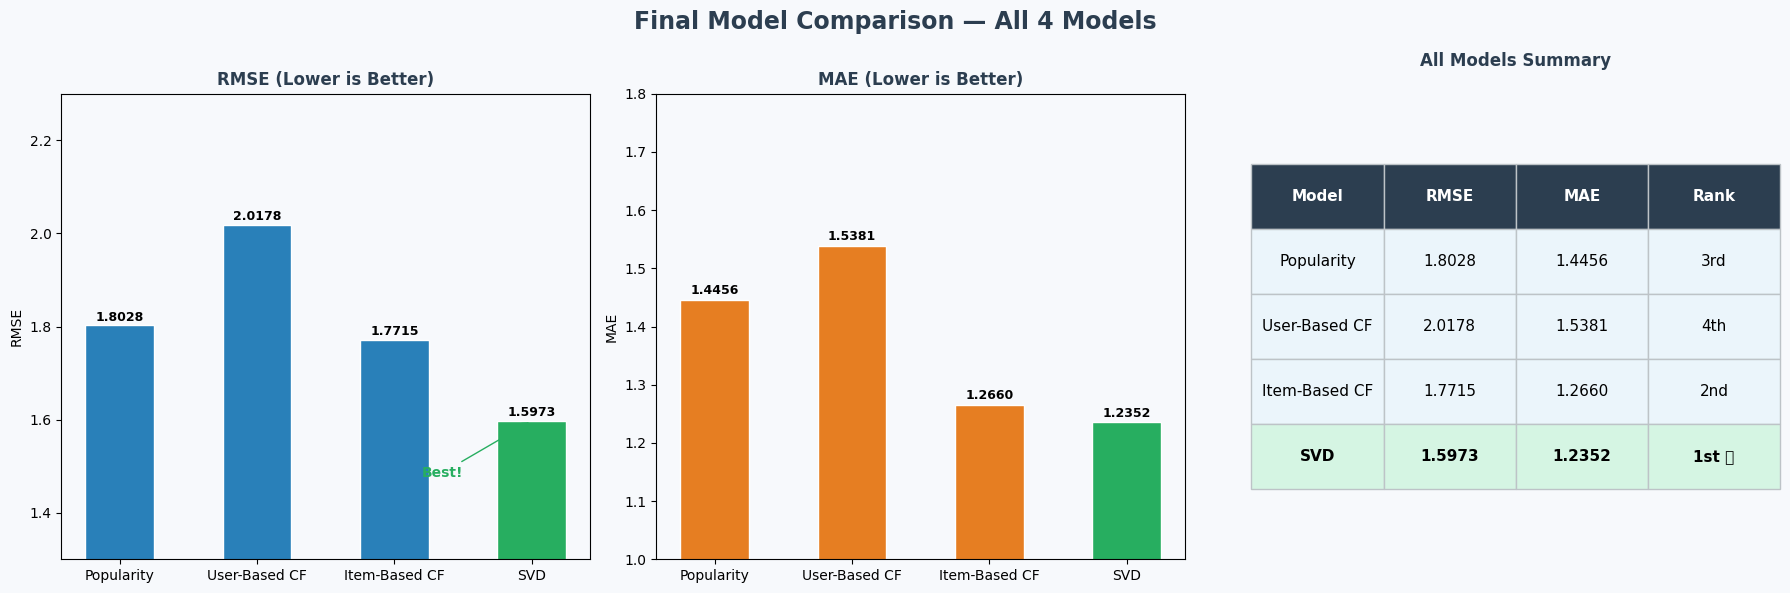

Saved: SVD_1_AllModels_Comparison.png


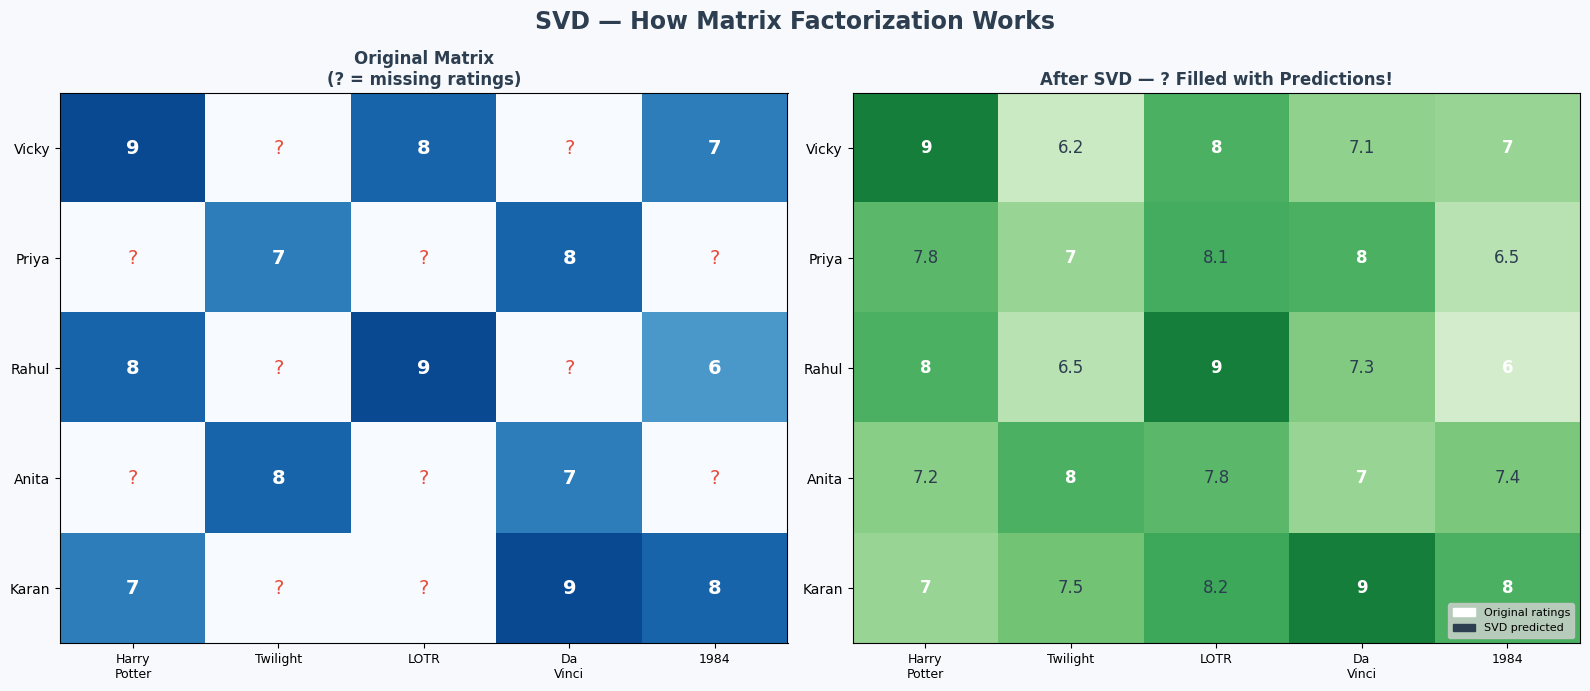

Saved: SVD_2_Explanation.png


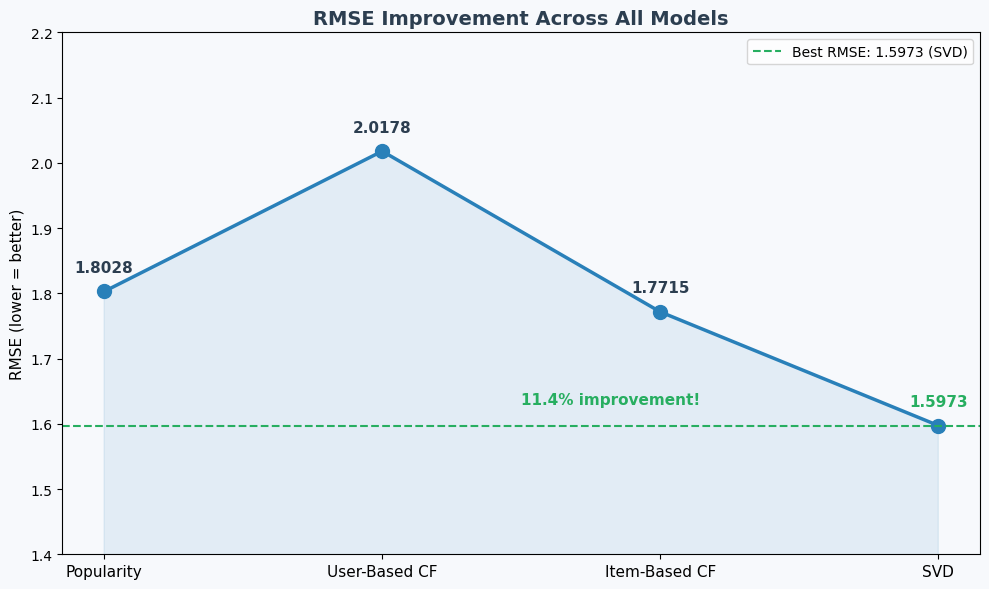

Saved: SVD_3_Improvement.png


In [10]:
# ================================================================
# SECTION 8: FINAL MODEL COMPARISON (ALL 4 MODELS)
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 8: FINAL MODEL COMPARISON")
print("=" * 55)
 
all_models    = ['Popularity', 'User-Based CF', 'Item-Based CF', 'SVD']
all_rmse_vals = [rmse_pop,     rmse_ucf,        rmse_icf,        rmse_svd]
all_mae_vals  = [mae_pop,      mae_ucf,         mae_icf,         mae_svd]
ranks         = ['3rd',        '4th',           '2nd',           '1st ✅']
 
print(f"\n{'Rank':<6} {'Model':<20} {'RMSE':>8} {'MAE':>8}")
print("-" * 46)
for rank, model, rmse, mae in zip(ranks, all_models, all_rmse_vals, all_mae_vals):
    marker = ' ← FINAL' if rank == '1st ✅' else ''
    print(f"{rank:<6} {model:<20} {rmse:>8.4f} {mae:>8.4f}{marker}")
 
improvement = ((rmse_pop - rmse_svd) / rmse_pop) * 100
print(f"\nSVD improved RMSE by {improvement:.1f}% over Popularity baseline!")
 
# ── Chart 1: All 4 Models Comparison ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Final Model Comparison — All 4 Models',
             fontsize=17, fontweight='bold', color=DARK)
 
ax = axes[0]
colors_r = [GREEN if r == min(all_rmse_vals) else BLUE for r in all_rmse_vals]
bars = ax.bar(all_models, all_rmse_vals, color=colors_r, edgecolor='white', width=0.5)
ax.set_title('RMSE (Lower is Better)', fontweight='bold', color=DARK)
ax.set_ylabel('RMSE'); ax.set_ylim(1.3, 2.3); ax.set_facecolor(BG)
for bar, val in zip(bars, all_rmse_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.annotate('Best!', xy=(3, min(all_rmse_vals)), xytext=(2.2, min(all_rmse_vals)-0.12),
            fontsize=10, color=GREEN, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GREEN))
 
ax = axes[1]
colors_m = [GREEN if m == min(all_mae_vals) else ORG for m in all_mae_vals]
bars2 = ax.bar(all_models, all_mae_vals, color=colors_m, edgecolor='white', width=0.5)
ax.set_title('MAE (Lower is Better)', fontweight='bold', color=DARK)
ax.set_ylabel('MAE'); ax.set_ylim(1.0, 1.8); ax.set_facecolor(BG)
for bar, val in zip(bars2, all_mae_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
 
ax = axes[2]
ax.axis('off')
table_data = [['Model','RMSE','MAE','Rank'],
              ['Popularity',   f'{rmse_pop:.4f}', f'{mae_pop:.4f}', '3rd'],
              ['User-Based CF',f'{rmse_ucf:.4f}', f'{mae_ucf:.4f}', '4th'],
              ['Item-Based CF',f'{rmse_icf:.4f}', f'{mae_icf:.4f}', '2nd'],
              ['SVD',          f'{rmse_svd:.4f}', f'{mae_svd:.4f}', '1st ✅']]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', bbox=[0, 0.15, 1, 0.7])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#BDC3C7')
    if r == 0:   cell.set_facecolor(DARK);     cell.set_text_props(color='white', fontweight='bold')
    elif r == 4: cell.set_facecolor('#D5F5E3'); cell.set_text_props(fontweight='bold')
    else:        cell.set_facecolor('#EBF5FB')
ax.set_title('All Models Summary', fontweight='bold', color=DARK, pad=20)
 
plt.tight_layout()
plt.savefig('SVD_1_AllModels_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: SVD_1_AllModels_Comparison.png")
 
# ── Chart 2: SVD Explanation Matrix ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('SVD — How Matrix Factorization Works',
             fontsize=17, fontweight='bold', color=DARK)
 
matrix = [['9','?','8','?','7'],['?','7','?','8','?'],
          ['8','?','9','?','6'],['?','8','?','7','?'],['7','?','?','9','8']]
filled = [['9','6.2','8','7.1','7'],['7.8','7','8.1','8','6.5'],
          ['8','6.5','9','7.3','6'],['7.2','8','7.8','7','7.4'],['7','7.5','8.2','9','8']]
books_lbl = ['Harry\nPotter','Twilight','LOTR','Da\nVinci','1984']
users_lbl = ['Vicky','Priya','Rahul','Anita','Karan']
 
ax = axes[0]
ax.set_title('Original Matrix\n(? = missing ratings)', fontweight='bold', color=DARK)
im = np.array([[float(v) if v!='?' else 0 for v in row] for row in matrix])
ax.imshow(im, cmap='Blues', vmin=0, vmax=10, aspect='auto')
for i in range(5):
    for j in range(5):
        val = matrix[i][j]
        ax.text(j, i, val, ha='center', va='center', fontsize=14,
                color='white' if val!='?' else RED,
                fontweight='bold' if val!='?' else 'normal')
ax.set_xticks(range(5)); ax.set_xticklabels(books_lbl, fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(users_lbl, fontsize=10)
 
ax = axes[1]
ax.set_title('After SVD — ? Filled with Predictions!', fontweight='bold', color=DARK)
im2 = np.array([[float(v) for v in row] for row in filled])
ax.imshow(im2, cmap='Greens', vmin=5, vmax=10, aspect='auto')
for i in range(5):
    for j in range(5):
        val  = filled[i][j]
        orig = matrix[i][j]
        ax.text(j, i, val, ha='center', va='center', fontsize=12,
                color='white' if orig!='?' else DARK,
                fontweight='bold' if orig!='?' else 'normal')
ax.set_xticks(range(5)); ax.set_xticklabels(books_lbl, fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(users_lbl, fontsize=10)
p1 = mpatches.Patch(color='white', label='Original ratings')
p2 = mpatches.Patch(color=DARK,    label='SVD predicted')
ax.legend(handles=[p1,p2], loc='lower right', fontsize=8, facecolor='lightgray')
 
plt.tight_layout()
plt.savefig('SVD_2_Explanation.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: SVD_2_Explanation.png")
 
# ── Chart 3: RMSE Improvement Line Chart ────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.set_title('RMSE Improvement Across All Models',
             fontsize=14, fontweight='bold', color=DARK)
x = range(len(all_models))
ax.plot(x, all_rmse_vals, marker='o', color=BLUE, linewidth=2.5, markersize=10)
ax.fill_between(x, all_rmse_vals, alpha=0.1, color=BLUE)
for i, (xi, yi) in enumerate(zip(x, all_rmse_vals)):
    color = GREEN if yi == min(all_rmse_vals) else DARK
    ax.annotate(f'{yi:.4f}', xy=(xi, yi), xytext=(xi, yi+0.03),
                ha='center', fontsize=11, fontweight='bold', color=color)
ax.set_xticks(x); ax.set_xticklabels(all_models, fontsize=11)
ax.set_ylabel('RMSE (lower = better)', fontsize=11)
ax.set_ylim(1.4, 2.2)
ax.axhline(min(all_rmse_vals), color=GREEN, linestyle='--', linewidth=1.5,
           label=f'Best RMSE: {min(all_rmse_vals):.4f} (SVD)')
ax.legend(fontsize=10)
ax.text(1.5, 1.63, f'{improvement:.1f}% improvement!',
        color=GREEN, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('SVD_3_Improvement.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: SVD_3_Improvement.png")

In [11]:
# ================================================================
# SECTION 9: FINAL SUMMARY
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 9: FINAL SUMMARY")
print("=" * 55)
print(f"""
ALL 4 MODELS COMPLETED:
 
  Model 1: Popularity-Based   RMSE: {rmse_pop:.4f}  MAE: {mae_pop:.4f}
  Model 2: User-Based CF      RMSE: {rmse_ucf:.4f}  MAE: {mae_ucf:.4f}
  Model 3: Item-Based CF      RMSE: {rmse_icf:.4f}  MAE: {mae_icf:.4f}
  Model 4: SVD                RMSE: {rmse_svd:.4f}  MAE: {mae_svd:.4f}  ← WINNER
 
FINAL MODEL: SVD (Matrix Factorization)
  - Best RMSE and MAE among all models
  - {improvement:.1f}% improvement over Popularity baseline
  - Handles sparse data well
  - Used by Netflix, Amazon, Spotify
 
HOW SVD RECOMMENDS:
  1. Learn hidden patterns (genres, styles) from ratings
  2. For new user → predict ratings for all unrated books
  3. Return top N books with highest predicted rating
""")


  SECTION 9: FINAL SUMMARY

ALL 4 MODELS COMPLETED:

  Model 1: Popularity-Based   RMSE: 1.8028  MAE: 1.4456
  Model 2: User-Based CF      RMSE: 2.0178  MAE: 1.5381
  Model 3: Item-Based CF      RMSE: 1.7715  MAE: 1.2660
  Model 4: SVD                RMSE: 1.5973  MAE: 1.2352  ← WINNER

FINAL MODEL: SVD (Matrix Factorization)
  - Best RMSE and MAE among all models
  - 11.4% improvement over Popularity baseline
  - Handles sparse data well
  - Used by Netflix, Amazon, Spotify

HOW SVD RECOMMENDS:
  1. Learn hidden patterns (genres, styles) from ratings
  2. For new user → predict ratings for all unrated books
  3. Return top N books with highest predicted rating



In [12]:
import pickle

with open("svd_model.pkl", "wb") as f:
    pickle.dump(svd_model, f)